In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from astropy.coordinates import SkyCoord
import astropy.coordinates as coord
import astropy.units as u
import random
import numpy as np

In [4]:
import pickle

In [5]:
sources_file = '/Volumes/thesis/rubin-sim/userdata/opsim_ml/rand_tristar_10_000_000.parquet'

In [6]:
sdf = pd.read_parquet(sources_file)

In [10]:
odf = sdf

In [11]:
ra = coord.Angle(odf['ra'].to_numpy()*u.degree)
ra = ra.wrap_at(180*u.degree)
dec = coord.Angle(odf['dec'].to_numpy()*u.degree)

In [12]:

radecs = SkyCoord(ra=ra, dec=dec, frame='icrs')

In [13]:
gc = radecs.transform_to(frame='galactic')

In [30]:
gc

<SkyCoord (Galactic): (l, b) in deg
    [(147.44455956, -35.17942885), (149.30102371, -35.27054337),
     (244.07322624, -18.40937696), ..., (279.4284266 , -35.16428822),
     (276.24805473, -36.84809533), (306.54419778, -45.11924367)]>

In [34]:
np.random.choice?

Docstring:
choice(a, size=None, replace=True, p=None)

Generates a random sample from a given 1-D array

.. versionadded:: 1.7.0

.. note::
    New code should use the `~numpy.random.Generator.choice`
    method of a `~numpy.random.Generator` instance instead;
    please see the :ref:`random-quick-start`.

Parameters
----------
a : 1-D array-like or int
    If an ndarray, a random sample is generated from its elements.
    If an int, the random sample is generated as if it were ``np.arange(a)``
size : int or tuple of ints, optional
    Output shape.  If the given shape is, e.g., ``(m, n, k)``, then
    ``m * n * k`` samples are drawn.  Default is None, in which case a
    single value is returned.
replace : boolean, optional
    Whether the sample is with or without replacement. Default is True,
    meaning that a value of ``a`` can be selected multiple times.
p : 1-D array-like, optional
    The probabilities associated with each entry in a.
    If not given, the sample assumes a unif

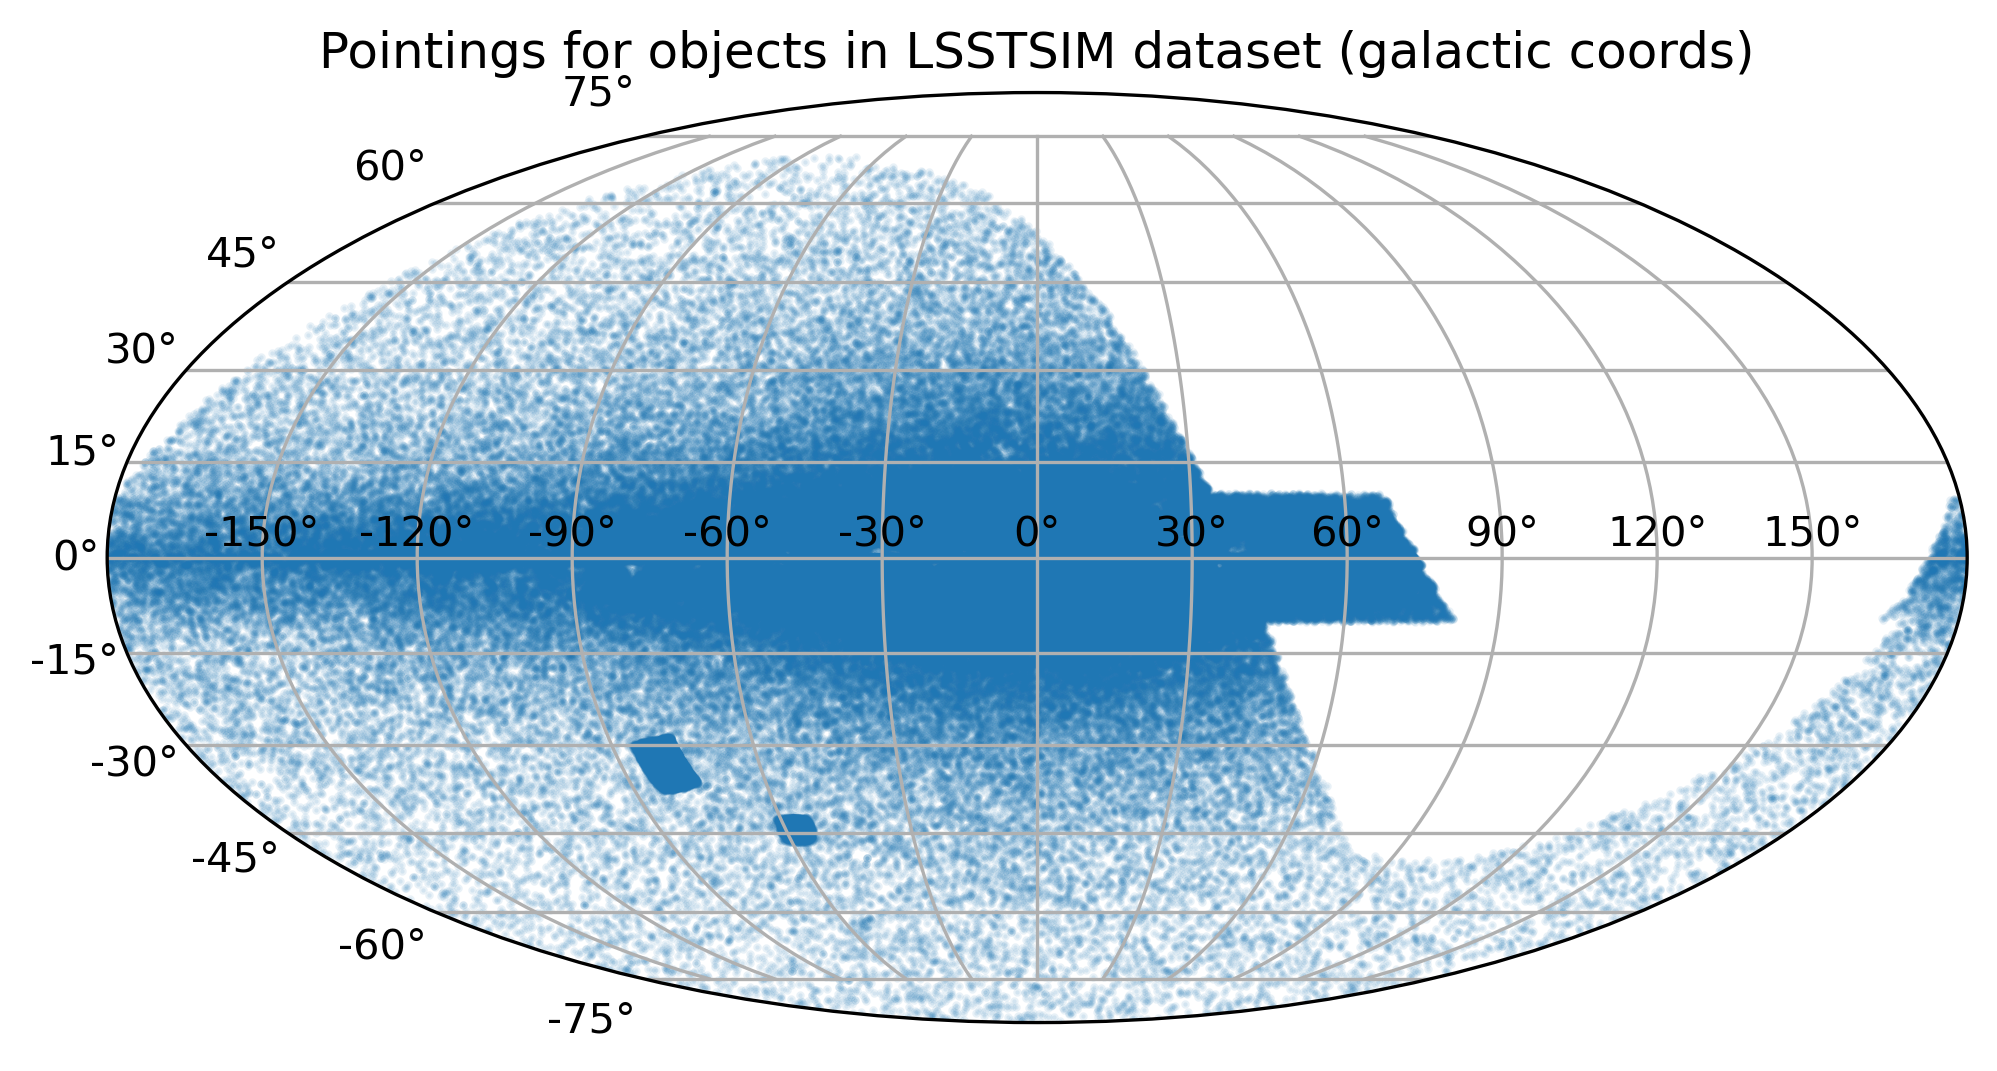

In [39]:
gcitems = np.random.choice(len(gc),500000)
subgc = gc[gcitems]
fig = plt.figure(figsize=(8,6),dpi=300)
ax = fig.add_subplot(111, projection="mollweide")
ax.scatter(subgc.l.wrap_at(180*u.degree).radian, subgc.b.radian,s=1,alpha=.1)
# ax.set_xticklabels(['14h','16h','18h','20h','22h','0h','2h','4h','6h','8h','10h'])
ax.grid(True)
ax.set_title('Pointings for objects in LSSTSIM dataset (galactic coords)')
# ax.text(galcenterra.radian, galcenterdec.radian, 'Galactic center')
# ax.plot(galcenterra.radian, galcenterdec.radian,'ro')
plt.savefig('/Users/duncan/Documents/code/physics/dissertation/ims/trilegal-map-gal.pdf')
plt.savefig('/Users/duncan/Documents/code/physics/dissertation/ims/trilegal-map-gal.png')

In [ ]:
random.choice?

Object `random.random.choice` not found.


In [25]:
random?

Type:        module
String form: <module 'random' from '/Users/duncan/mambaforge/envs/rubinsim/lib/python3.11/random.py'>
File:        ~/mambaforge/envs/rubinsim/lib/python3.11/random.py
Docstring:  
Random variable generators.

    bytes
    -----
           uniform bytes (values between 0 and 255)

    integers
    --------
           uniform within range

    sequences
    ---------
           pick random element
           pick random sample
           pick weighted random sample
           generate random permutation

    distributions on the real line:
    ------------------------------
           uniform
           triangular
           normal (Gaussian)
           lognormal
           negative exponential
           gamma
           beta
           pareto
           Weibull

    distributions on the circle (angles 0 to 2pi)
    ---------------------------------------------
           circular uniform
           von Mises

General notes on the underlying Mersenne Twister core ge